In [33]:
import os
import glob
import shutil
import pandas as pd
from PIL import Image

# Output directory expected by XYDataset
OUTPUT_DIR = 'dataset_xy'
os.makedirs(OUTPUT_DIR, exist_ok=True)

dataset_root = 'dataset'
session_csvs = glob.glob(os.path.join(dataset_root, '*.csv'))

copied, skipped = 0, 0

for csv_path in session_csvs:
    session_name = os.path.splitext(os.path.basename(csv_path))[0]
    image_dir = os.path.join(dataset_root, session_name)

    if not os.path.isdir(image_dir):
        print(f"Skipping {session_name} — no matching image folder found")
        continue

    df = pd.read_csv(csv_path, header=None, names=['frame', 'x', 'y'])

    for _, row in df.iterrows():
        frame_id = int(row['frame'])
        x, y = row['x'], row['y']

        src = os.path.join(image_dir, f'{frame_id:04d}.jpg')
        if not os.path.exists(src):
            skipped += 1
            continue

        # Filename encodes x and y as integers scaled to [0, 1000]
        # get_x/get_y in XYDataset decode them back assuming width=height=1000
        # x is in [0,1], y is in [-1,1] → convert to pixel coords in a 224x224 image
        x_int = int(x * 224)                    # [0,1]   → [0, 224]
        y_int = int((y + 1.0) / 2.0 * 224)     # [-1,1]  → [0, 224]

        dst_name = f'xy_{x_int:03d}_{y_int:03d}_{session_name}_{frame_id:04d}.jpg'

        dst_name = f'xy_{x_int}_{y_int}_{session_name}_{frame_id:04d}.jpg'
        dst = os.path.join(OUTPUT_DIR, dst_name)
        shutil.copy(src, dst)
        copied += 1

print(f"Done: {copied} images copied, {skipped} skipped (missing files)")

Done: 7584 images copied, 0 skipped (missing files)


# Road Follower - Train Model

In this notebook we will train a neural network to take an input image, and output a set of x, y values corresponding to a target.

We will be using PyTorch deep learning framework to train ResNet18 neural network architecture model for road follower application.

In [34]:
import torch
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.datasets as datasets
import torchvision.models as models
import torchvision.transforms as transforms
import glob
import PIL.Image
import os
import numpy as np

### Download and extract data

Before you start, you should upload the ``road_following_<Date&Time>.zip`` file that you created in the ``data_collection.ipynb`` notebook on the robot. 

> If you're training on the JetBot you collected data on, you can skip this!

You should then extract this dataset by calling the command below:

In [21]:
!unzip -q road_following.zip

unzip:  cannot find or open road_following.zip, road_following.zip.zip or road_following.zip.ZIP.


You should see a folder named ``dataset_all`` appear in the file browser.

### Create Dataset Instance

Here we create a custom ``torch.utils.data.Dataset`` implementation, which implements the ``__len__`` and ``__getitem__`` functions.  This class
is responsible for loading images and parsing the x, y values from the image filenames.  Because we implement the ``torch.utils.data.Dataset`` class,
we can use all of the torch data utilities :)

We hard coded some transformations (like color jitter) into our dataset.  We made random horizontal flips optional (in case you want to follow a non-symmetric path, like a road
where we need to 'stay right').  If it doesn't matter whether your robot follows some convention, you could enable flips to augment the dataset.

In [35]:
def get_x(path, width):
    """Gets the x value from the image filename"""
    return (float(int(path.split("_")[1])) - width/2) / (width/2)

def get_y(path, height):
    """Gets the y value from the image filename"""
    return (float(int(path.split("_")[2])) - height/2) / (height/2)

# def get_x(path, width):
#     return float(int(path.split("_")[1])) / 1000.0

# def get_y(path, height):
#     return (float(int(path.split("_")[2])) / 1000.0) * 2.0 - 1.0

class XYDataset(torch.utils.data.Dataset):
    
    def __init__(self, directory, random_hflips=False):
        self.directory = directory
        self.random_hflips = random_hflips
        self.image_paths = glob.glob(os.path.join(self.directory, '*.jpg'))
        self.color_jitter = transforms.ColorJitter(0.3, 0.3, 0.3, 0.3)
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        
        image = PIL.Image.open(image_path)
        width, height = image.size
        x = float(get_x(os.path.basename(image_path), width))
        y = float(get_y(os.path.basename(image_path), height))
      
        if float(np.random.rand(1)) > 0.5:
            image = transforms.functional.hflip(image)
            x = -x
        
        image = self.color_jitter(image)
        image = transforms.functional.resize(image, (224, 224))
        image = transforms.functional.to_tensor(image)
        image = image.numpy()[::-1].copy()
        image = torch.from_numpy(image)
        image = transforms.functional.normalize(image, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        
        return image, torch.tensor([x, y]).float()

dataset = XYDataset('dataset_xy', random_hflips=False)

### Split dataset into train and test sets
Once we read dataset, we will split data set in train and test sets. In this example we split train and test a 90%-10%. The test set will be used to verify the accuracy of the model we train.

In [36]:
used_percent = 0.9
used, not_used = torch.utils.data.random_split(dataset, [int(used_percent * len(dataset)), len(dataset) - int(used_percent * len(dataset))])
test_percent = 0.1
num_test = int(test_percent * len(used))
train_dataset, test_dataset = torch.utils.data.random_split(used, [len(used) - num_test, num_test])

### Create data loaders to load data in batches

We use ``DataLoader`` class to load data in batches, shuffle data and allow using multi-subprocesses. In this example we use batch size of 64. Batch size will be based on memory available with your GPU and it can impact accuracy of the model.

In [37]:
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

### Define Neural Network Model 

We use ResNet-18 model available on PyTorch TorchVision. 

In a process called transfer learning, we can repurpose a pre-trained model (trained on millions of images) for a new task that has possibly much less data available.


More details on ResNet-18 : https://github.com/pytorch/vision/blob/master/torchvision/models/resnet.py

More Details on Transfer Learning: https://www.youtube.com/watch?v=yofjFQddwHE 

In [38]:
model = models.resnet18(pretrained=True)

In [39]:
model.fc = torch.nn.Linear(512, 2)
device = torch.device('cuda')
model = model.to(device)
print(device)

cuda


In [ ]:
NUM_EPOCHS = 5
BEST_MODEL_PATH = 'best_steering_model_xy.pth'
best_loss = 1e9

optimizer = optim.Adam(model.parameters())

for epoch in range(NUM_EPOCHS):
    print(f'Epoch {epoch+1}/{NUM_EPOCHS} — ', end='')
    model.train()
    train_loss = 0.0
    for images, labels in iter(train_loader):
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        train_loss += float(loss)
        loss.backward()
        optimizer.step()
    train_loss /= len(train_loader)
    
    model.eval()
    test_loss = 0.0
    for images, labels in iter(test_loader):
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        loss = F.mse_loss(outputs, labels)
        test_loss += float(loss)
    test_loss /= len(test_loader)
    
    print('%f, %f' % (train_loss, test_loss))
    if test_loss < best_loss:
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        best_loss = test_loss

Epoch 1/5 — 

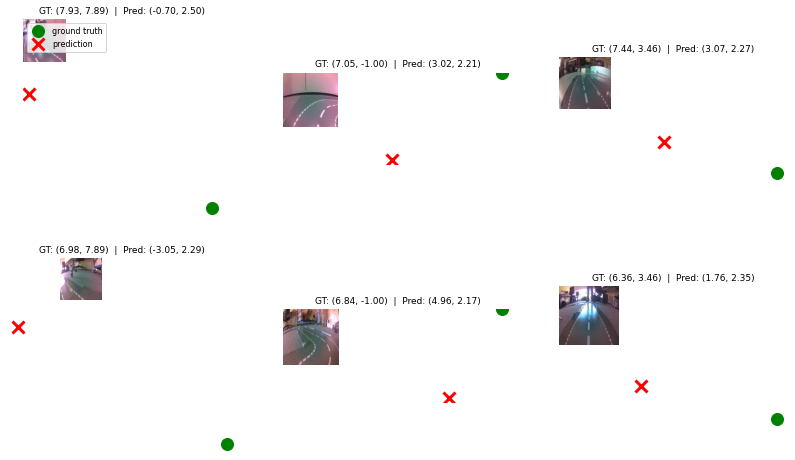

In [31]:
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import PIL.Image
import os


state_dict = torch.load('best_steering_model_xy.pth', map_location='cpu')
model.eval()

# Pick N random images from dataset_xy
sample_paths = random.sample(dataset.image_paths, 6)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, image_path in zip(axes, sample_paths):
    # Load and preprocess
    image = PIL.Image.open(image_path)
    
    # Get ground truth from filename
    x_true = get_x(os.path.basename(image_path), image.size[0])
    y_true = get_y(os.path.basename(image_path), image.size[1])
    
    # Preprocess for model (same as __getitem__ but without augmentation)
    import torchvision.transforms as transforms
    img_tensor = transforms.functional.resize(image, (224, 224))
    img_tensor = transforms.functional.to_tensor(img_tensor)
    img_tensor = transforms.functional.normalize(img_tensor, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    img_tensor = img_tensor.unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(img_tensor).cpu().numpy().flatten()
    
    x_pred, y_pred = output[0], output[1]
    
    # Display image
    ax.imshow(image)
    w, h = image.size
    
    # Draw ground truth (green) and prediction (red) as dots
    # x is in [0,1] → map to pixel width; y is in [-1,1] → map to pixel height
    # Ground truth: x in [-1,1], y in [-1,1] → map to pixel space
    gt_px = (x_true + 1.0) / 2.0 * w
    gt_py = (y_true + 1.0) / 2.0 * h

    # Prediction: same mapping
    pred_px = (x_pred + 1.0) / 2.0 * w
    pred_py = (y_pred + 1.0) / 2.0 * h
    
    ax.plot(gt_px, gt_py, 'go', markersize=12, label='ground truth')
    ax.plot(pred_px, pred_py, 'rx', markersize=12, markeredgewidth=3, label='prediction')
    
    ax.set_title(f'GT: ({x_true:.2f}, {y_true:.2f})  |  Pred: ({x_pred:.2f}, {y_pred:.2f})', fontsize=9)
    ax.axis('off')

axes[0].legend(loc='upper left', fontsize=8)

Once the model is trained, it will generate ``best_steering_model_xy.pth`` file which you can use for inferencing in the live demo notebook.

If you trained on a different machine other than JetBot, you'll need to upload this to the JetBot to the ``road_following`` example folder.

In [ ]:
import torch
state_dict = torch.load('best_steering_model_xy.pth', map_location='cpu')
torch.save(state_dict, 'best_steering_model_xy_cpu.pth', _use_new_zipfile_serialization=False)